<a href="https://colab.research.google.com/github/magnogomes874/MVP/blob/main/MVP_Planejamento_Nova_Unidade_DataCenter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MAGNO GOMES SOUSA

200031031



# **Planejamento da Implantação de uma Nova Unidade de Data Center**



Desenvolver um modelo para apoiar a decisão de implantação de uma nova unidade de armazenamento de dados em nuvem, analisando **custos, prazos e riscos** a partir de dados de estoque e cadeia de suprimentos.


A análise utiliza como referência a base **Inventory Dataset for Complex Supply Chains**, disponível no Kaggle.

In [1]:

# 1. Bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import io

pd.set_option("display.max_columns", None)

print("Tudo pronto para começar!")


Tudo pronto para começar!



# 2. Carregar a base do Kaggle



In [3]:

# 2.1 Upload do arquivo do Kaggle (.zip ou .csv)

from google.colab import files
import zipfile
import io
import pandas as pd

print("Selecione o arquivo baixado do Kaggle:")
uploaded = files.upload()

nome_arquivo = next(iter(uploaded))

# Verifica se o arquivo é ZIP
if nome_arquivo.lower().endswith(".zip"):

    print("\n📦 Arquivo ZIP identificado.")

    with zipfile.ZipFile(io.BytesIO(uploaded[nome_arquivo]), "r") as zip_ref:

        # Lista os arquivos dentro do ZIP
        arquivos = zip_ref.namelist()
        print("Arquivos encontrados:")

        for arquivo in arquivos:
            print(" -", arquivo)

        # Procura um CSV
        csvs = [arquivo for arquivo in arquivos if arquivo.lower().endswith(".csv")]

        if len(csvs) == 0:
            raise Exception("❌ Nenhum arquivo CSV foi encontrado dentro do ZIP.")

        csv_nome = csvs[0]

        print("\n📄 CSV encontrado:", csv_nome)

        # Extrai e lê o CSV
        dados_csv = zip_ref.read(csv_nome)

        try:
            df = pd.read_csv(io.BytesIO(dados_csv), encoding="utf-8")
        except UnicodeDecodeError:
            df = pd.read_csv(io.BytesIO(dados_csv), encoding="latin1")

else:
    # Caso você envie diretamente o CSV
    print("\n📄 Arquivo CSV identificado.")

    try:
        df = pd.read_csv(
            io.BytesIO(uploaded[nome_arquivo]),
            encoding="utf-8"
        )
    except UnicodeDecodeError:
        df = pd.read_csv(
            io.BytesIO(uploaded[nome_arquivo]),
            encoding="latin1"
        )

print("\n✅ Base carregada com sucesso!")
print("Arquivo enviado:", nome_arquivo)
print("Quantidade de registros:", len(df))
print("Quantidade de colunas:", len(df.columns))

print("\n📊 Primeiras linhas da base:")
display(df.head())


Selecione o arquivo baixado do Kaggle:


Saving archive.zip to archive (1).zip

📦 Arquivo ZIP identificado.
Arquivos encontrados:
 - Inventory_Dataset.csv

📄 CSV encontrado: Inventory_Dataset.csv

✅ Base carregada com sucesso!
Arquivo enviado: archive (1).zip
Quantidade de registros: 3100
Quantidade de colunas: 12

📊 Primeiras linhas da base:


,date,product_id,warehouse_id,historical_demand,demand_variability,current_inventory,reorder_point,lead_time_days,holding_cost,ordering_cost,shortage_cost,target_operational_cost
0,2022-01-01,1051,2,117,0.320712,240,125,8,3.328840,89.125640,23.859310,888.047353
1,2022-01-02,1092,3,123,0.209622,78,107,6,4.628331,80.445656,12.973182,1025.248670
2,2022-01-03,1014,1,107,0.126077,97,86,5,1.924135,39.398371,9.595929,321.998795
3,2022-01-04,1071,1,122,0.119969,299,183,9,1.477149,61.859766,11.532677,503.527230
4,2022-01-05,1060,4,110,0.146223,275,150,12,0.979533,34.735082,22.055504,304.106651


In [4]:

# Informações Importantes

print("Tamanho da base:", df.shape)
print("\nColunas:")
for coluna in df.columns:
    print("-", coluna)

print("\nTipos de dados:")
display(df.dtypes.to_frame("tipo"))

print("\nValores ausentes:")
display(df.isna().sum().to_frame("quantidade"))


Tamanho da base: (3100, 12)

Colunas:
- date
- product_id
- warehouse_id
- historical_demand
- demand_variability
- current_inventory
- reorder_point
- lead_time_days
- holding_cost
- ordering_cost
- shortage_cost
- target_operational_cost

Tipos de dados:


,tipo
date,object
product_id,int64
warehouse_id,int64
historical_demand,int64
demand_variability,float64
current_inventory,int64
reorder_point,int64
lead_time_days,int64
holding_cost,float64
ordering_cost,float64



Valores ausentes:


,quantidade
date,0
product_id,0
warehouse_id,0
historical_demand,0
demand_variability,0
current_inventory,0
reorder_point,0
lead_time_days,0
holding_cost,0
ordering_cost,0


In [5]:

# 3.1 Estatísticas principais

display(df.describe().T)


,count,mean,std,min,25%,50%,75%,max
product_id,3100.0,1048.537097,29.327774,1000.000000,1023.000000,1048.000000,1074.000000,1099.000000
warehouse_id,3100.0,3.023871,1.410127,1.000000,2.000000,3.000000,4.000000,5.000000
historical_demand,3100.0,120.255161,10.959151,82.000000,113.000000,120.000000,127.000000,159.000000
demand_variability,3100.0,0.298829,0.117425,0.100063,0.195018,0.295416,0.404369,0.499538
current_inventory,3100.0,271.834839,130.677357,50.000000,159.000000,270.000000,387.000000,499.000000
reorder_point,3100.0,139.684194,34.641965,80.000000,110.000000,139.000000,170.000000,199.000000
lead_time_days,3100.0,7.544516,4.076980,1.000000,4.000000,7.000000,11.000000,14.000000
holding_cost,3100.0,2.815511,1.307770,0.500217,1.710465,2.853730,3.959910,4.999554
ordering_cost,3100.0,59.947733,22.794595,20.008819,40.337444,59.870077,79.124514,99.956042
shortage_cost,3100.0,14.801866,5.691748,5.002503,9.804982,14.772723,19.591807,24.993912



## O que encontramos?

A base possui informações sobre:

- demanda histórica;
- variabilidade da demanda;
- estoque atual;
- ponto de reposição;
- lead time;
- custos de estoque;
- custos de pedido;
- custo de falta;
- custo operacional.



In [6]:

# 4. Preparação dos dados

df["date"] = pd.to_datetime(df["date"])

# Garantir que as variáveis numéricas sejam realmente numéricas
numericas = [
    "historical_demand",
    "demand_variability",
    "current_inventory",
    "reorder_point",
    "lead_time_days",
    "holding_cost",
    "ordering_cost",
    "shortage_cost",
    "target_operational_cost"
]

for coluna in numericas:
    df[coluna] = pd.to_numeric(df[coluna], errors="coerce")

# Remover linhas que ficaram incompletas nas variáveis principais
df = df.dropna(subset=numericas).copy()

print("Base pronta para análise:", df.shape)


Base pronta para análise: (3100, 12)



# 5. Visão geral do estoque


### Perguntas que serão respondias com base nos dados

**Quanto existe em estoque?**

**Quanto é demandado?**

**Quantos registros estão abaixo do ponto de reposição?**

**Qual é o custo operacional médio?**


In [8]:

estoque_total = df["current_inventory"].sum()
demanda_total = df["historical_demand"].sum()
abaixo_reposicao = (df["current_inventory"] < df["reorder_point"]).sum()
percentual_abaixo = abaixo_reposicao / len(df) * 100
custo_operacional_medio = df["target_operational_cost"].mean()

print(" Estoque total:", f"{estoque_total:,.0f}")
print(" Demanda total:", f"{demanda_total:,.0f}")
print(" Registros abaixo do ponto de reposição:", abaixo_reposicao)
print(" Percentual abaixo do ponto de reposição:", f"{percentual_abaixo:.1f}%")
print(" Custo operacional médio:", f"R$ {custo_operacional_medio:,.2f}")


 Estoque total: 842,688
 Demanda total: 372,791
 Registros abaixo do ponto de reposição: 638
 Percentual abaixo do ponto de reposição: 20.6%
 Custo operacional médio: R$ 909.97


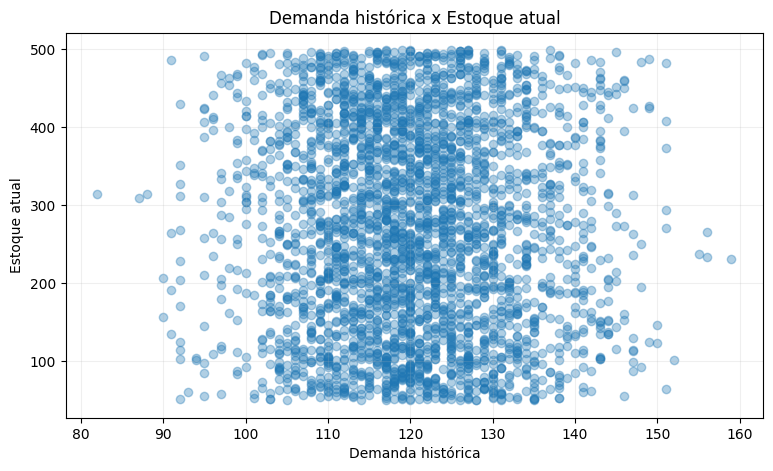

In [9]:

# 5.1 Comparação entre demanda e estoque

plt.figure(figsize=(9,5))
plt.scatter(df["historical_demand"], df["current_inventory"], alpha=0.35)
plt.xlabel("Demanda histórica")
plt.ylabel("Estoque atual")
plt.title("Demanda histórica x Estoque atual")
plt.grid(alpha=0.2)
plt.show()



# 6. 🚨 Identificando risco

O recurso será considerado mais arriscado quando:

- o estoque estiver abaixo do ponto de reposição;
- a demanda for alta;
- a variabilidade da demanda for alta;
- o lead time do fornecedor for alto.


In [10]:

# 6.1 Criar indicadores simples

df["estoque_vs_reposicao"] = (
    df["current_inventory"] / df["reorder_point"].replace(0, np.nan)
).fillna(0)

# Quanto menor o estoque em relação ao ponto de reposição, maior o risco
df["risco_estoque"] = np.where(
    df["current_inventory"] < df["reorder_point"], 100, 0
)

# Transformações simples para colocar tudo aproximadamente na mesma escala
def escala_0_100(serie):
    minimo = serie.min()
    maximo = serie.max()
    if maximo == minimo:
        return pd.Series(50, index=serie.index)
    return (serie - minimo) / (maximo - minimo) * 100

df["risco_demanda"] = escala_0_100(df["historical_demand"])
df["risco_variabilidade"] = escala_0_100(df["demand_variability"])
df["risco_lead_time"] = escala_0_100(df["lead_time_days"])

# Pesos simples
df["risco_total"] = (
    0.40 * df["risco_estoque"] +
    0.20 * df["risco_demanda"] +
    0.20 * df["risco_variabilidade"] +
    0.20 * df["risco_lead_time"]
)

def classificar_risco(valor):
    if valor < 30:
        return "BAIXO"
    elif valor < 60:
        return "MÉDIO"
    elif valor < 80:
        return "ALTO"
    else:
        return "CRÍTICO"

df["classe_risco"] = df["risco_total"].apply(classificar_risco)

display(
    df[
        [
            "product_id",
            "warehouse_id",
            "current_inventory",
            "reorder_point",
            "lead_time_days",
            "risco_total",
            "classe_risco"
        ]
    ].head(10)
)


,product_id,warehouse_id,current_inventory,reorder_point,lead_time_days,risco_total,classe_risco
0,1051,2,240,125,8,30.907074,MÉDIO
1,1092,3,78,107,6,63.826789,ALTO
2,1014,1,97,86,5,13.949764,BAIXO
3,1071,1,299,183,9,23.693906,BAIXO
4,1060,4,275,150,12,26.506817,BAIXO
5,1020,1,321,173,2,15.432052,BAIXO
6,1082,4,202,161,7,32.250978,MÉDIO
7,1086,4,377,167,6,27.802850,BAIXO
8,1074,4,334,85,7,28.042520,BAIXO
9,1074,1,229,137,12,35.168426,MÉDIO


In [11]:

# 6.2 Os 10 recursos que mais merecem atenção

top_riscos = df.sort_values("risco_total", ascending=False).head(10)

display(
    top_riscos[
        [
            "product_id",
            "warehouse_id",
            "historical_demand",
            "current_inventory",
            "reorder_point",
            "lead_time_days",
            "shortage_cost",
            "risco_total",
            "classe_risco"
        ]
    ]
)


,product_id,warehouse_id,historical_demand,current_inventory,reorder_point,lead_time_days,shortage_cost,risco_total,classe_risco
2752,1081,4,146,153,157,14,18.228060,91.850253,CRÍTICO
1339,1046,2,127,61,114,13,21.934222,90.136894,CRÍTICO
1737,1041,2,131,103,165,12,22.440375,89.621037,CRÍTICO
2479,1076,5,127,104,126,14,10.463332,89.609341,CRÍTICO
1570,1046,1,131,106,117,14,10.453781,89.497390,CRÍTICO
86,1013,2,126,144,158,13,6.135615,88.901824,CRÍTICO
2330,1034,3,134,103,126,11,16.727049,88.868107,CRÍTICO
917,1049,5,137,65,157,14,23.529189,88.724233,CRÍTICO
1903,1074,4,126,145,163,14,19.917591,88.596253,CRÍTICO
2550,1054,2,130,154,176,14,15.615239,87.968159,CRÍTICO


In [12]:

# 6.3 Quantidade que precisa ser reposta

df["quantidade_reposicao"] = (
    df["reorder_point"] - df["current_inventory"]
).clip(lower=0)

df["custo_falta_estimado"] = (
    df["quantidade_reposicao"] * df["shortage_cost"]
)

print("Quantidade total estimada para reposição:",
      f"{df['quantidade_reposicao'].sum():,.0f}")

print("Custo de falta potencial associado:",
      f"R$ {df['custo_falta_estimado'].sum():,.2f}")


Quantidade total estimada para reposição: 32,121
Custo de falta potencial associado: R$ 478,778.33



# 7.  Análise de custos

A base possui três tipos importantes de custo:

- **Holding cost:** custo de manter estoque;
- **Ordering cost:** custo associado ao pedido;
- **Shortage cost:** custo da falta.

-  `target_operational_cost: É usado como referência de custo operacional.



In [13]:

# Custos médios

custos = pd.DataFrame({
    "Indicador": [
        "Holding cost médio",
        "Ordering cost médio",
        "Shortage cost médio",
        "Custo operacional médio"
    ],
    "Valor": [
        df["holding_cost"].mean(),
        df["ordering_cost"].mean(),
        df["shortage_cost"].mean(),
        df["target_operational_cost"].mean()
    ]
})

custos["Valor"] = custos["Valor"].round(2)

display(custos)


,Indicador,Valor
0,Holding cost médio,2.82
1,Ordering cost médio,59.95
2,Shortage cost médio,14.80
3,Custo operacional médio,909.97


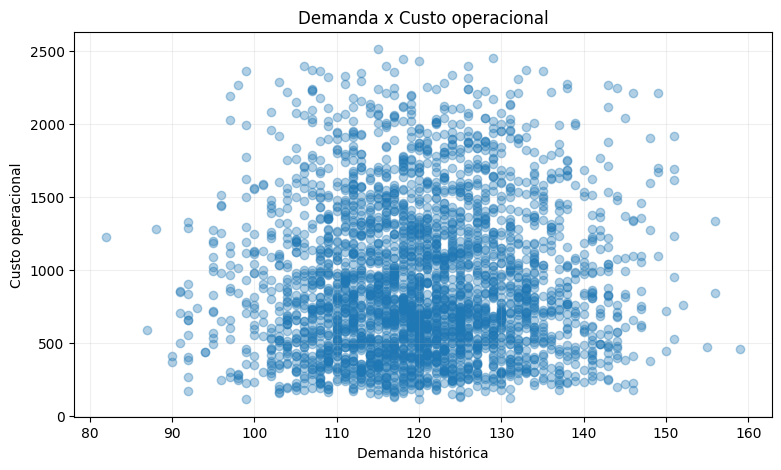

In [14]:

# Relação entre custo operacional e demanda

plt.figure(figsize=(9,5))
plt.scatter(
    df["historical_demand"],
    df["target_operational_cost"],
    alpha=0.35
)
plt.xlabel("Demanda histórica")
plt.ylabel("Custo operacional")
plt.title("Demanda x Custo operacional")
plt.grid(alpha=0.2)
plt.show()



# 8. Análise de tempo

Para uma nova unidade, o prazo de compra dos recursos é muito importante.

A pergunta é:

> **Qual recurso possui o maior lead time e pode virar um gargalo?**

Nesse caso, estamos utilizando o `lead_time_days` como um alerta inicial.


In [15]:

lead_time_medio = df["lead_time_days"].mean()
lead_time_maximo = df["lead_time_days"].max()

recurso_critico_tempo = df.loc[
    df["lead_time_days"].idxmax()
]

print("⏱️ Lead time médio:", f"{lead_time_medio:.1f} dias")
print("⏱️ Maior lead time:", f"{lead_time_maximo:.0f} dias")

print("\nRecurso que apresenta o maior lead time:")
display(
    recurso_critico_tempo[
        [
            "product_id",
            "warehouse_id",
            "lead_time_days",
            "current_inventory",
            "reorder_point",
            "risco_total"
        ]
    ].to_frame("valor")
)


⏱️ Lead time médio: 7.5 dias
⏱️ Maior lead time: 14 dias

Recurso que apresenta o maior lead time:


,valor
product_id,1059
warehouse_id,5
lead_time_days,14
current_inventory,58
reorder_point,130
risco_total,82.733856



# 9. Simulação da nova unidade



In [16]:

# 9.1 PREMISSAS DO PROJETO
# Altere estes valores para testar outros cenários.

custo_implantacao = 5_000_000       # obras, instalação e infraestrutura
custo_equipamentos = 8_000_000     # equipamentos da nova unidade
contingencia = 0.10                # 10% para imprevistos

prazo_implantacao_dias = 120       # obras/instalação
prazo_configuracao_dias = 30       # configuração e testes

# Fator de escala:
# 1.0 = tamanho semelhante ao cenário de referência
# 1.5 = unidade 50% maior
# 2.0 = unidade duas vezes maior
fator_escala = 1.0

# Benefício/capacidade financeira estimada por ano.
# É uma premissa para o cálculo simples de retorno.
beneficio_anual = 3_500_000

print("Premissas carregadas.")


Premissas carregadas.


In [19]:

# 9.2 Cálculo do custo total

custo_base = (
    custo_implantacao +
    custo_equipamentos
) * fator_escala

valor_contingencia = custo_base * contingencia

investimento_total = custo_base + valor_contingencia

print("Custo de implantação:", f"R$ {custo_implantacao * fator_escala:,.2f}")
print("Custo de equipamentos:", f"R$ {custo_equipamentos * fator_escala:,.2f}")
print("Reserva para imprevistos:", f"R$ {valor_contingencia:,.2f}")
print("INVESTIMENTO TOTAL:", f"R$ {investimento_total:,.2f}")


Custo de implantação: R$ 5,000,000.00
Custo de equipamentos: R$ 8,000,000.00
Reserva para imprevistos: R$ 1,300,000.00
INVESTIMENTO TOTAL: R$ 14,300,000.00


In [20]:

# 9.3 Cálculo simples do prazo

prazo_recursos = lead_time_maximo
prazo_total_estimado = (
    prazo_implantacao_dias +
    prazo_configuracao_dias +
    prazo_recursos
)

print("Prazo de implantação:", prazo_implantacao_dias, "dias")
print("Prazo de configuração/testes:", prazo_configuracao_dias, "dias")
print("Maior lead time dos recursos:", int(prazo_recursos), "dias")
print("------------------------------------------------")
print(" PRAZO ESTIMADO DO PROJETO:",
      int(prazo_total_estimado), "dias")

print("Aproximadamente:",
      round(prazo_total_estimado / 30, 1), "meses")


Prazo de implantação: 120 dias
Prazo de configuração/testes: 30 dias
Maior lead time dos recursos: 14 dias
------------------------------------------------
 PRAZO ESTIMADO DO PROJETO: 164 dias
Aproximadamente: 5.5 meses



# **Para simplificar o MVP**


**obras + configuração/testes + maior lead time**

Pensando em projeto real, vários desses processos poderiam acontecer **ao mesmo tempo**. Por isso, este cálculo deve ser entendido como uma **estimativa conservadora para o MVP**, e não como um cronograma definitivo.


In [21]:

# 10. Retorno simples do investimento

# Payback simples
if beneficio_anual > 0:
    payback_anos = investimento_total / beneficio_anual
else:
    payback_anos = np.inf

print("Investimento:", f"R$ {investimento_total:,.2f}")
print("Benefício anual estimado:", f"R$ {beneficio_anual:,.2f}")
print("💵 Payback estimado:", f"{payback_anos:.2f} anos")


Investimento: R$ 14,300,000.00
Benefício anual estimado: R$ 3,500,000.00
💵 Payback estimado: 4.09 anos



# 11. Índice final de risco da nova unidade

# Juntando os três pontos:

### 40% — Risco de abastecimento
Baseado nos recursos analisados.

### 30% — Risco de prazo
Quanto maior o lead time crítico, maior a atenção necessária.

### 30% — Risco financeiro
Quanto maior o investimento em relação ao benefício anual, maior o risco.



In [23]:

# 11.1 Cálculo do risco financeiro

# Quanto menor o número de anos para recuperar o investimento, menor o risco.
if payback_anos <= 3:
    risco_financeiro = 20
elif payback_anos <= 5:
    risco_financeiro = 40
elif payback_anos <= 7:
    risco_financeiro = 65
else:
    risco_financeiro = 85

# Risco de prazo
if prazo_total_estimado <= 180:
    risco_prazo = 25
elif prazo_total_estimado <= 270:
    risco_prazo = 50
elif prazo_total_estimado <= 365:
    risco_prazo = 70
else:
    risco_prazo = 90

# Risco médio dos recursos
risco_abastecimento = df["risco_total"].mean()

risco_final = (
    0.40 * risco_abastecimento +
    0.30 * risco_prazo +
    0.30 * risco_financeiro
)

if risco_final < 30:
    classificacao_final = "BAIXO"
elif risco_final < 60:
    classificacao_final = "MÉDIO"
elif risco_final < 80:
    classificacao_final = "ALTO"
else:
    classificacao_final = "CRÍTICO"

print("Risco de abastecimento:", f"{risco_abastecimento:.1f}/100")
print("Risco de prazo:", f"{risco_prazo}/100")
print("Risco financeiro:", f"{risco_financeiro}/100")
print("--------------------------------")
print("RISCO FINAL:", f"{risco_final:.1f}/100")
print("Classificação:", classificacao_final)


Risco de abastecimento: 38.2/100
Risco de prazo: 25/100
Risco financeiro: 40/100
--------------------------------
RISCO FINAL: 34.8/100
Classificação: MÉDIO


In [24]:

# 12. Recomendação

# Regra simples e fácil de explicar
if risco_final <= 40 and payback_anos <= 5:
    recomendacao = "IMPLEMENTAR"
elif risco_final <= 65 and payback_anos <= 7:
    recomendacao = "REVISAR PROJETO"
else:
    recomendacao = "NÃO IMPLEMENTAR"

print("==========================================")
print("        RESULTADO DO MVP")
print("==========================================")
print("Investimento total:", f"R$ {investimento_total:,.2f}")
print("Prazo estimado:", f"{prazo_total_estimado:.0f} dias")
print("Payback:", f"{payback_anos:.2f} anos")
print("Risco:", f"{risco_final:.1f}/100")
print("Classificação:", classificacao_final)
print("------------------------------------------")
print("RECOMENDAÇÃO:", recomendacao)
print("==========================================")


        RESULTADO DO MVP
Investimento total: R$ 14,300,000.00
Prazo estimado: 164 dias
Payback: 4.09 anos
Risco: 34.8/100
Classificação: MÉDIO
------------------------------------------
RECOMENDAÇÃO: IMPLEMENTAR



# 13. Painel executivo



/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128181 (\N{BANKNOTE WITH DOLLAR SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/pytho

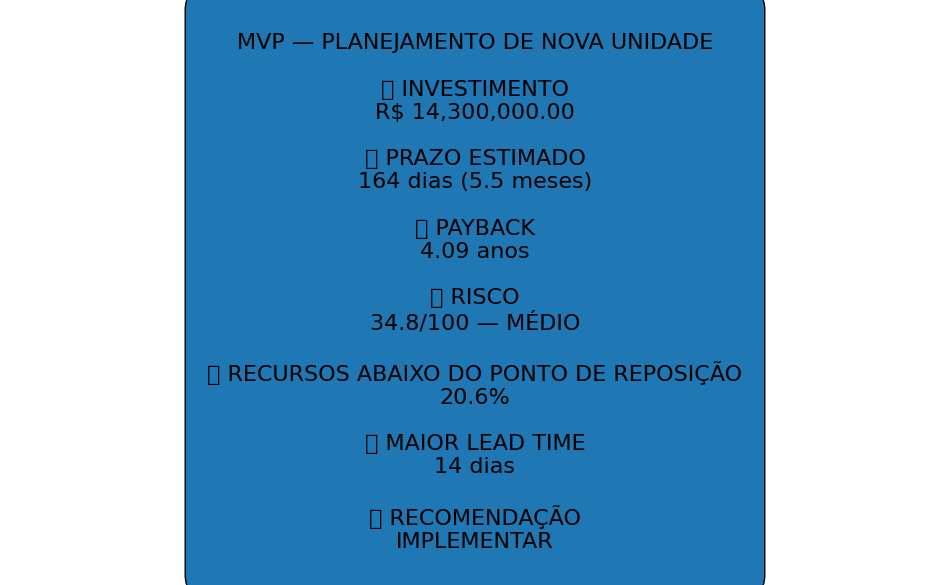

In [25]:

# Dashboard simples

fig, ax = plt.subplots(figsize=(12, 6))
ax.axis("off")

texto = f'''
MVP — PLANEJAMENTO DE NOVA UNIDADE

💰 INVESTIMENTO
R$ {investimento_total:,.2f}

⏱️ PRAZO ESTIMADO
{prazo_total_estimado:.0f} dias ({prazo_total_estimado/30:.1f} meses)

💵 PAYBACK
{payback_anos:.2f} anos

🚨 RISCO
{risco_final:.1f}/100 — {classificacao_final}

📦 RECURSOS ABAIXO DO PONTO DE REPOSIÇÃO
{percentual_abaixo:.1f}%

⏳ MAIOR LEAD TIME
{lead_time_maximo:.0f} dias

🎯 RECOMENDAÇÃO
{recomendacao}
'''

ax.text(
    0.5, 0.5, texto,
    ha="center", va="center",
    fontsize=16,
    bbox=dict(boxstyle="round,pad=1")
)

plt.show()


In [26]:

# Lista de atenção

lista_atencao = (
    df.sort_values(
        ["risco_total", "lead_time_days"],
        ascending=[False, False]
    )
    .head(15)
    [
        [
            "product_id",
            "warehouse_id",
            "current_inventory",
            "reorder_point",
            "quantidade_reposicao",
            "lead_time_days",
            "shortage_cost",
            "risco_total",
            "classe_risco"
        ]
    ]
)

display(lista_atencao)


,product_id,warehouse_id,current_inventory,reorder_point,quantidade_reposicao,lead_time_days,shortage_cost,risco_total,classe_risco
2752,1081,4,153,157,4,14,18.228060,91.850253,CRÍTICO
1339,1046,2,61,114,53,13,21.934222,90.136894,CRÍTICO
1737,1041,2,103,165,62,12,22.440375,89.621037,CRÍTICO
2479,1076,5,104,126,22,14,10.463332,89.609341,CRÍTICO
1570,1046,1,106,117,11,14,10.453781,89.497390,CRÍTICO
86,1013,2,144,158,14,13,6.135615,88.901824,CRÍTICO
2330,1034,3,103,126,23,11,16.727049,88.868107,CRÍTICO
917,1049,5,65,157,92,14,23.529189,88.724233,CRÍTICO
1903,1074,4,145,163,18,14,19.917591,88.596253,CRÍTICO
2550,1054,2,154,176,22,14,15.615239,87.968159,CRÍTICO



# 15. Planejamento da nova unidade
Identificar recursos críticos e prazos.

Planejar compras conforme os riscos.

Definir estoques de segurança.

Programar implantação e instalação.

Monitorar custos, prazos e riscos.

Revisar a estratégia quando necessário.



# 16. Exportar os resultados

Gerando um Excel com as principais informações.

In [27]:

# Exportação

resumo = pd.DataFrame({
    "Indicador": [
        "Investimento total",
        "Prazo estimado (dias)",
        "Payback (anos)",
        "Risco final",
        "Classificação de risco",
        "Recomendação",
        "Percentual abaixo do ponto de reposição",
        "Maior lead time (dias)"
    ],
    "Resultado": [
        investimento_total,
        prazo_total_estimado,
        payback_anos,
        risco_final,
        classificacao_final,
        recomendacao,
        percentual_abaixo,
        lead_time_maximo
    ]
})

arquivo_saida = "/content/Resultado_MVP_Nova_Unidade.xlsx"

with pd.ExcelWriter(arquivo_saida, engine="openpyxl") as writer:
    resumo.to_excel(writer, sheet_name="Resumo", index=False)
    lista_atencao.to_excel(writer, sheet_name="Recursos_Criticos", index=False)
    custos.to_excel(writer, sheet_name="Custos", index=False)
    df.to_excel(writer, sheet_name="Base_Analisada", index=False)

print("✅ Arquivo Excel criado:")
print(arquivo_saida)

files.download(arquivo_saida)


✅ Arquivo Excel criado:
/content/Resultado_MVP_Nova_Unidade.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


# 17. Conclusão

O MVP utiliza dados históricos para apoiar a decisão de implantação de uma nova unidade, considerando três fatores principais:

Custo — investimento e custos operacionais;

Tempo — prazos e lead time dos recursos;

Risco — abastecimento, prazo e impacto financeiro.

